Библиотеки загружены
car_data.csv: 280 строк, 9 столбцов
CAR_DETAILS_FROM_CAR_DEKHO.csv: 4036 строк, 8 столбцов
Car_details_v3.csv: 7559 строк, 13 столбцов

Объединённый датасет: 11875 строк, 16 столбцов
Колонки: ['name', 'year', 'price', 'present_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'car_age', 'source', 'mileage', 'engine', 'max_power', 'torque', 'seats']
               year         price  present_price     km_driven       car_age  \
count  11875.000000  1.187500e+04     280.000000  1.187500e+04  11875.000000   
mean    2013.558232  5.755610e+05       7.470929  6.779149e+04     12.441768   
std        4.101566  7.258874e+05       7.296562  5.351635e+04      4.101566   
min     1983.000000  1.000000e-01       0.320000  1.000000e+00      6.000000   
25%     2011.000000  2.250000e+05       1.050000  3.400000e+04      9.000000   
50%     2014.000000  4.000000e+05       6.445000  6.000000e+04     12.000000   
75%     2017.000000  6.500000e+05       9.910000 

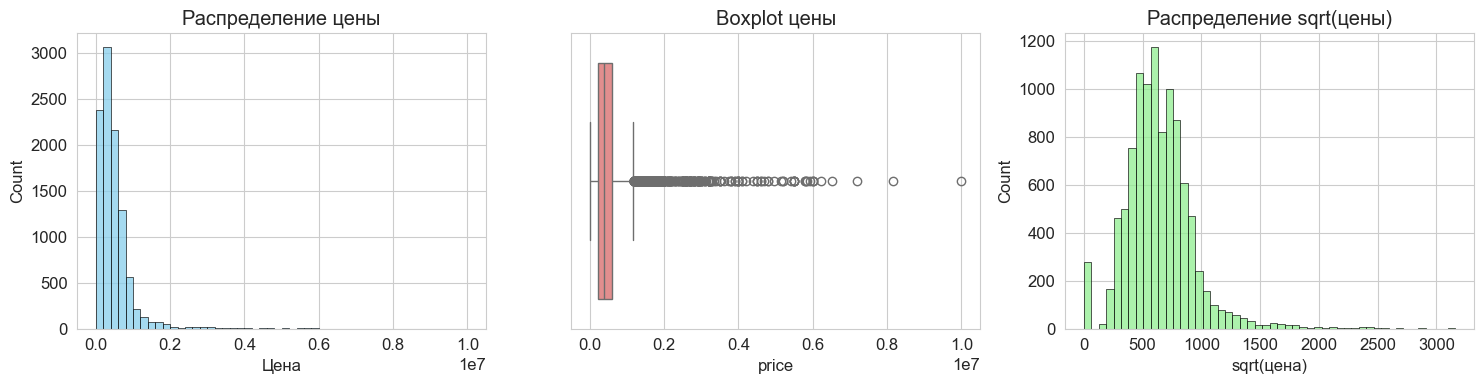

Асимметрия исходной цены: 5.261
Асимметрия sqrt(цены): 1.303

Вывод: Цена имеет сильную правостороннюю асимметрию. Логарифмирование рекомендуется.


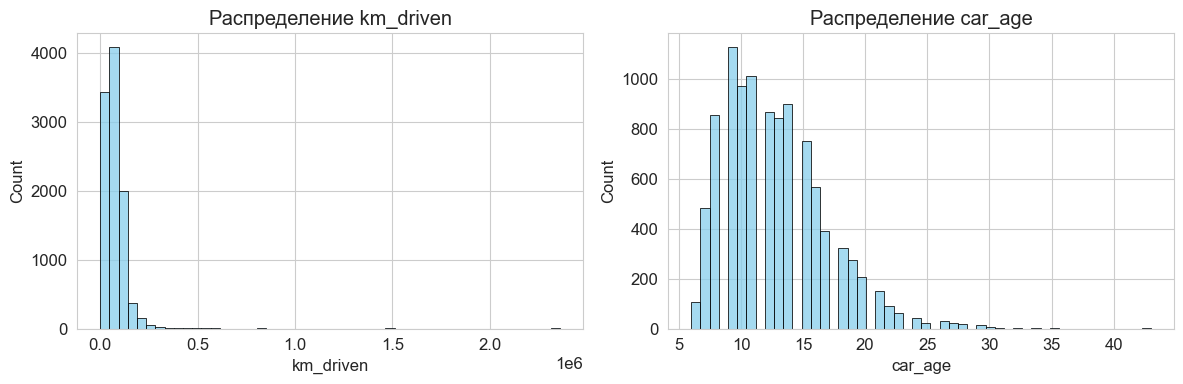

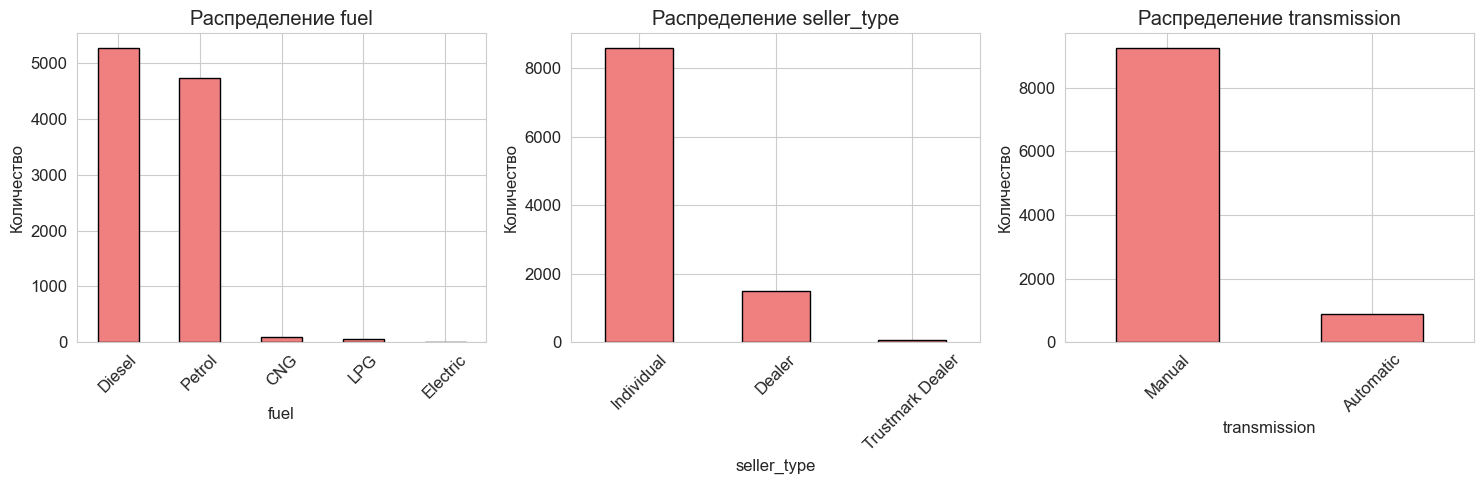

Уникальные значения в owner:
owner
First Owner             6084
Second Owner            2765
Third Owner              775
0                        268
Fourth & Above Owner     220
Test Drive Car            22
1                          9
3                          1
Name: count, dtype: int64


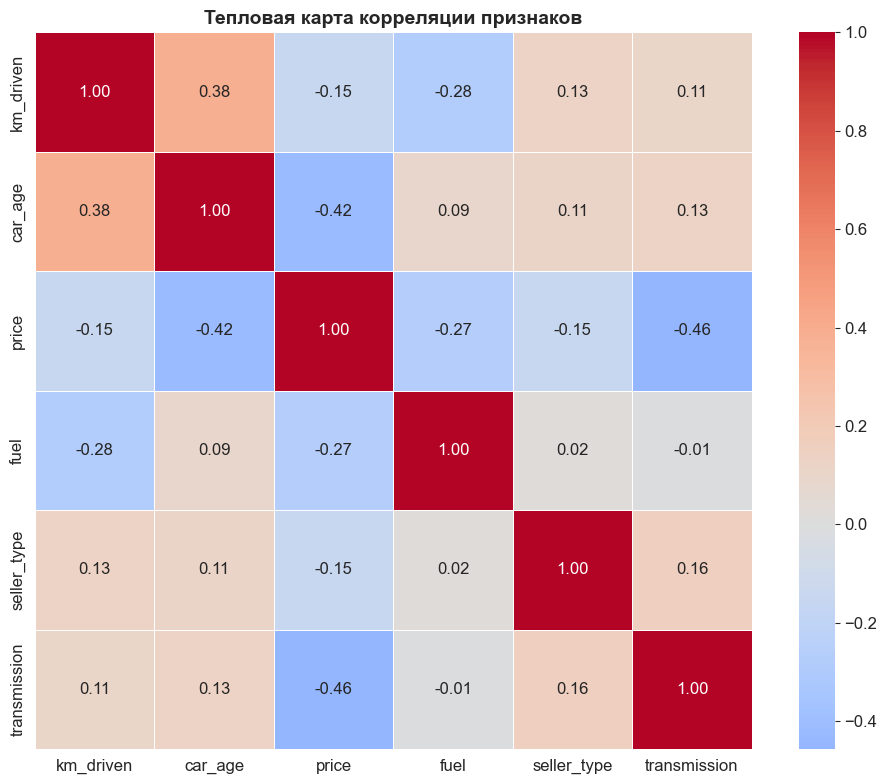

Корреляция признаков с ценой:
  km_driven: -0.150 (отрицательная, слабая)
  seller_type: -0.152 (отрицательная, слабая)
  fuel: -0.267 (отрицательная, слабая)
  car_age: -0.420 (отрицательная, средняя)
  transmission: -0.456 (отрицательная, средняя)


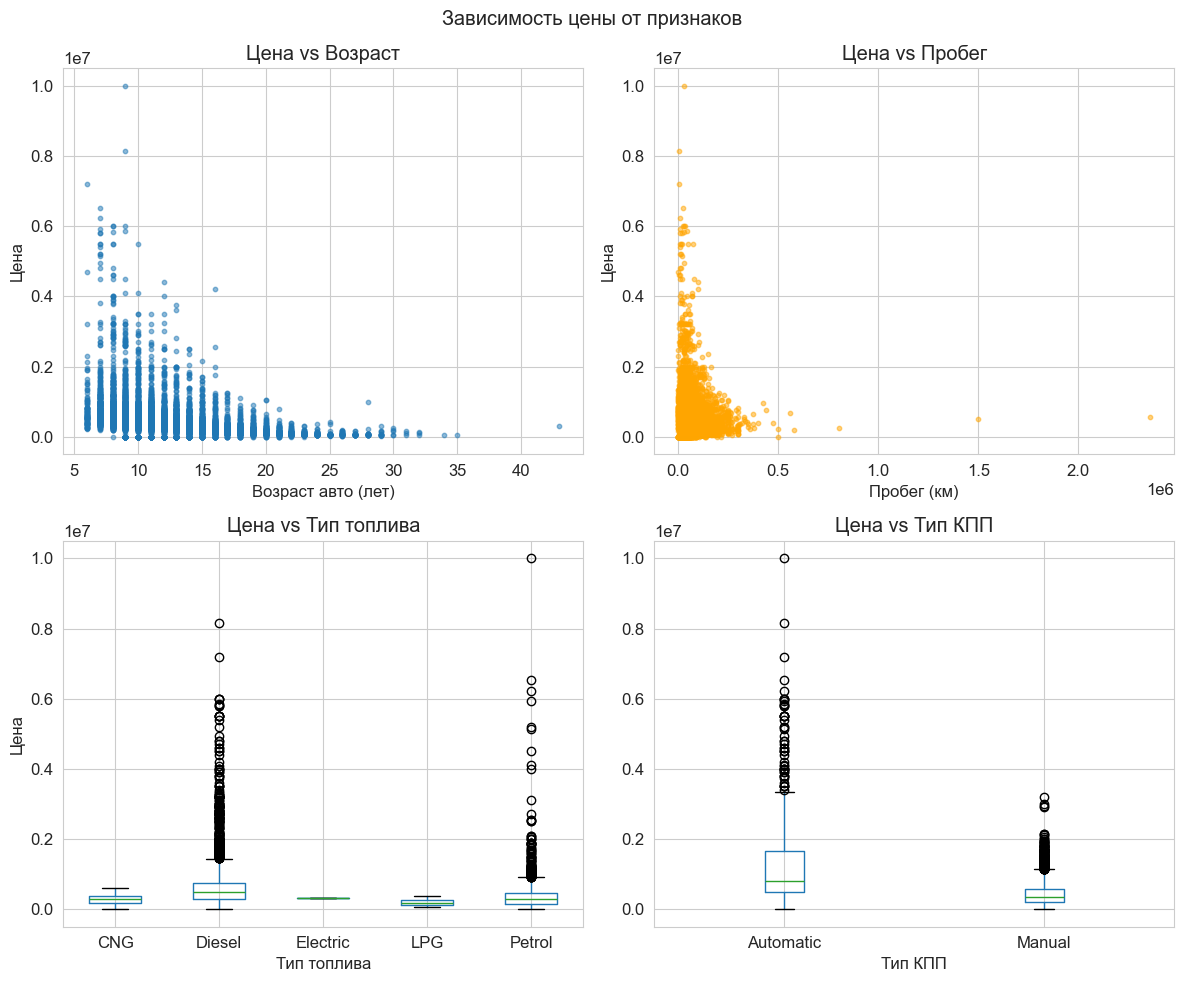

Топ-20 брендов по частоте встречаемости:
brand
maruti           3044
hyundai          1785
mahindra          983
tata              890
honda             570
ford              548
toyota            487
chevrolet         343
renault           298
volkswagen        250
nissan            116
skoda             114
datsun             82
bmw                71
fiat               70
mercedes-benz      66
audi               60
bajaj              25
city               25
jeep               24
Name: count, dtype: int64

Топ-10 брендов по средней цене:
brand
lexus            5.150000e+06
volvo            3.779167e+06
land             3.274875e+06
bmw              2.610070e+06
jaguar           2.529250e+06
mercedes-benz    2.268773e+06
audi             2.261783e+06
mg               1.807000e+06
jeep             1.766792e+06
isuzu            1.752500e+06
Name: price, dtype: float64


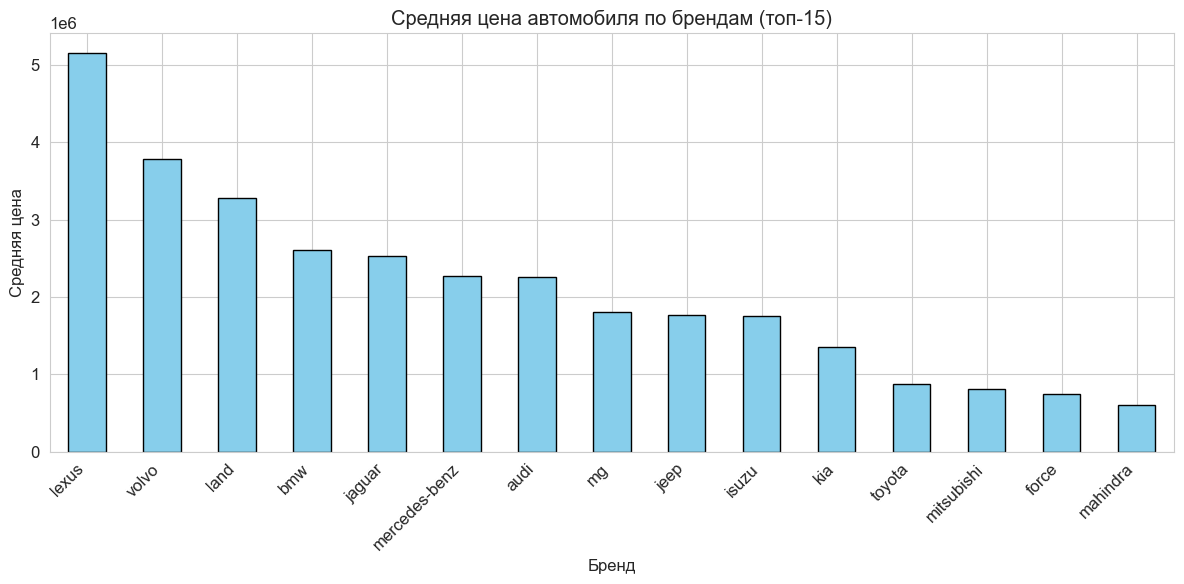

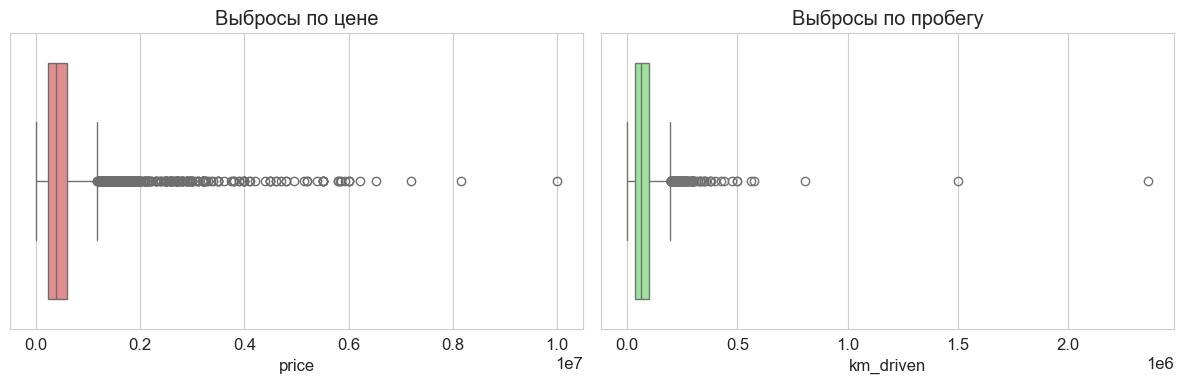

Количество выбросов по цене (метод IQR): 522 (5.1%)


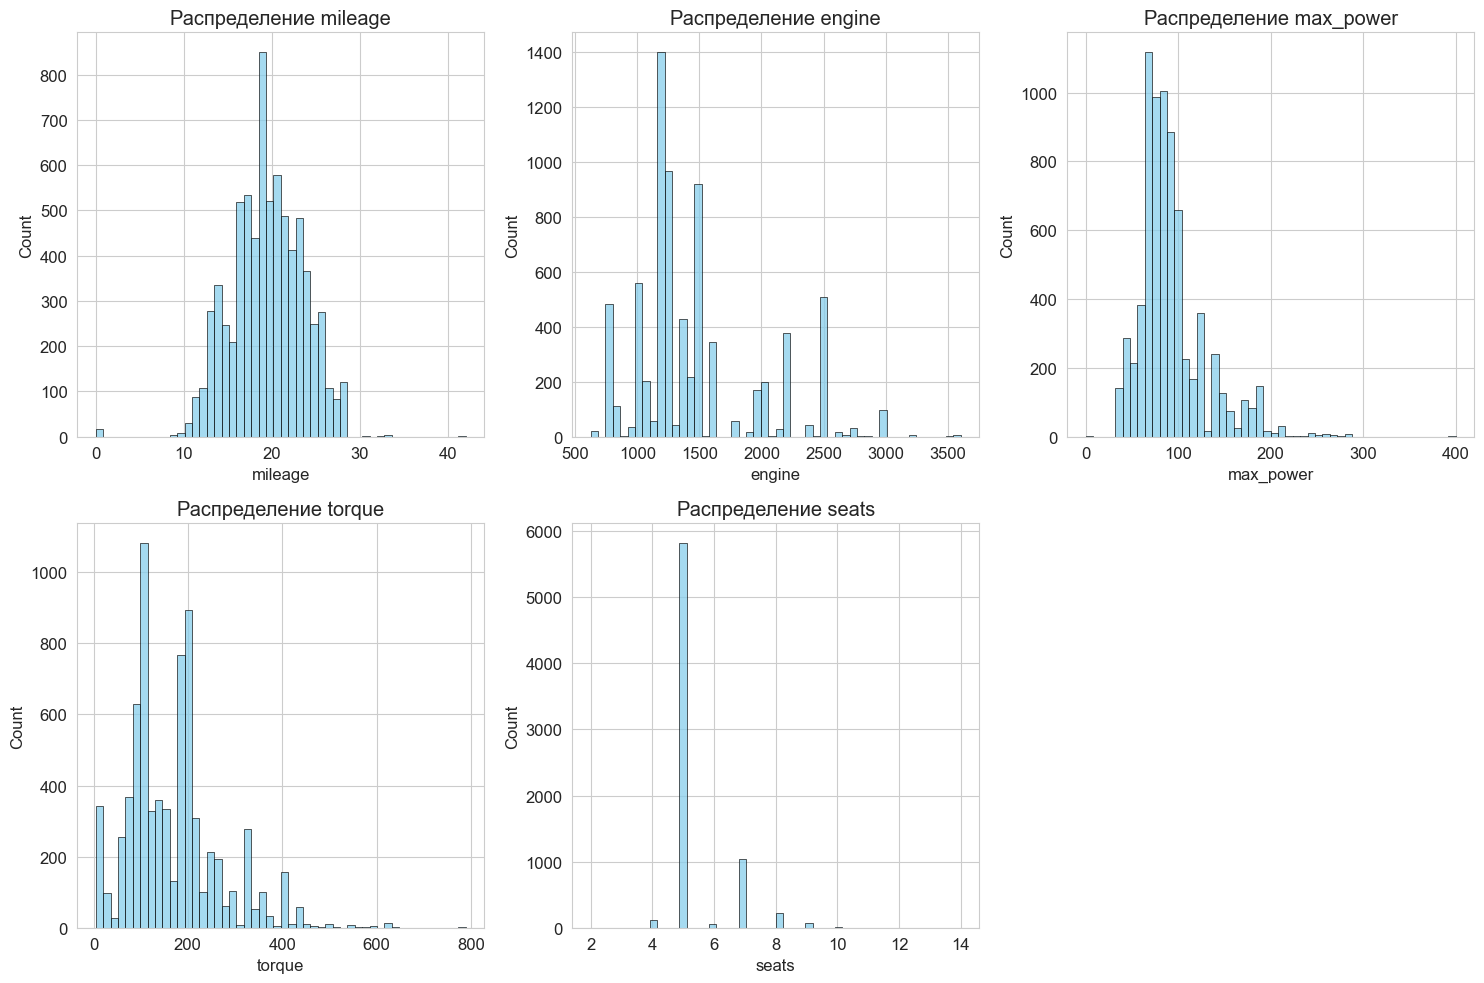

In [1]:
#!/usr/bin/env python
# coding: utf-8

# # Лабораторная работа №1-2
# ## Разведочный анализ данных (EDA)
# 
# **Тема:** Методы искусственного интеллекта. EDA. Линейная регрессия. Дерево решений. CatBoost. XGBoost. Нейронные сети (MLP).
# 
# **Цель:** Анализ первичных данных, определение влияния признаков и выбор наиболее подходящих для предсказания цены автомобиля.

# ## 1. Импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Библиотеки загружены")


# ## 2. Загрузка и объединение данных

# Загрузка трёх файлов
df1 = pd.read_csv('../data/raw/car_data.csv')
df2 = pd.read_csv('../data/raw/CAR_DETAILS_FROM_CAR_DEKHO.csv')
df3 = pd.read_csv('../data/raw/Car_details_v3.csv')

print(f"car_data.csv: {df1.shape[0]} строк, {df1.shape[1]} столбцов")
print(f"CAR_DETAILS_FROM_CAR_DEKHO.csv: {df2.shape[0]} строк, {df2.shape[1]} столбцов")
print(f"Car_details_v3.csv: {df3.shape[0]} строк, {df3.shape[1]} столбцов")


# Приведение названий колонок к единому формату
df1.columns = df1.columns.str.lower()
df2.columns = df2.columns.str.lower()
df3.columns = df3.columns.str.lower()

# Переименование колонок для единообразия
df1 = df1.rename(columns={
    'car_name': 'name',
    'selling_price': 'price',
    'present_price': 'present_price',
    'kms_driven': 'km_driven',
    'fuel_type': 'fuel',
    'seller_type': 'seller_type',
    'transmission': 'transmission',
    'owner': 'owner'
})

df2 = df2.rename(columns={'selling_price': 'price', 'km_driven': 'km_driven'})
df3 = df3.rename(columns={'selling_price': 'price', 'km_driven': 'km_driven'})

# Добавление возраста автомобиля
current_year = 2026
for df in [df1, df2, df3]:
    if 'year' in df.columns:
        df['car_age'] = current_year - df['year']

# Добавление источника данных
df1['source'] = 'car_data'
df2['source'] = 'car_dekho'
df3['source'] = 'car_details_v3'

# Объединение всех данных
df = pd.concat([df1, df2, df3], ignore_index=True)
print(f"\nОбъединённый датасет: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Колонки: {df.columns.tolist()}")


# ## 3. Первичный анализ данных

# Первые 5 строк
# print(df.head())


# # Информация о данных
# print(df.info())


# Статистика числовых признаков
print(df.describe())


# Проверка пропусков
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)
missing_df = pd.DataFrame({'missing': missing, 'percent': missing_percent})
missing_df[missing_df['missing'] > 0].sort_values('percent', ascending=False)

df=df.drop_duplicates()
# Проверка дубликатов
print(f"Полных дубликатов строк: {df.duplicated().sum()}")
print(f"Дубликатов по name: {df.duplicated(subset=['name']).sum()}")

# mean=df['price'].mean()
# std=df['price'].std()
# price_min=mean-2*std
# price_max=mean+2*std
# # print(df['price'])
# for n in df['price'].values:
#     if n<price_min or n>price_max:
#         df['price']=df['price'].drop(n)
# ## 4. Анализ целевой переменной (price)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Гистограмма
sns.histplot(df['price'], bins=50, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Распределение цены')
axes[0].set_xlabel('Цена')
#qwe

# Boxplot
sns.boxplot(x=df['price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot цены')

# Логарифмированное распределение
sns.histplot(np.sqrt(df['price']), bins=50, ax=axes[2], color='lightgreen', edgecolor='black')
axes[2].set_title('Распределение sqrt(цены)')
axes[2].set_xlabel('sqrt(цена)')

plt.tight_layout()
plt.savefig('../reports/figures/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


from scipy.stats import skew

price_skew = skew(df['price'].dropna())
price_sqrt_skew = skew(np.sqrt(df['price'].dropna()))

print(f"Асимметрия исходной цены: {price_skew:.3f}")
print(f"Асимметрия sqrt(цены): {price_sqrt_skew:.3f}")

if price_skew > 1:
    print("\nВывод: Цена имеет сильную правостороннюю асимметрию. Логарифмирование рекомендуется.")


# ## 5. Анализ числовых признаков

numeric_cols = ['km_driven', 'car_age']
existing_numeric = [c for c in numeric_cols if c in df.columns]

fig, axes = plt.subplots(1, len(existing_numeric), figsize=(12, 4))
if len(existing_numeric) == 1:
    axes = [axes]

for i, col in enumerate(existing_numeric):
    sns.histplot(df[col], bins=50, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.savefig('../reports/figures/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# ## 6. Анализ категориальных признаков

categorical_cols = ['fuel', 'seller_type', 'transmission']
existing_cat = [c for c in categorical_cols if c in df.columns]

fig, axes = plt.subplots(1, len(existing_cat), figsize=(15, 5))
if len(existing_cat) == 1:
    axes = [axes]

for i, col in enumerate(existing_cat):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='lightcoral', edgecolor='black')
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# Анализ owner
if 'owner' in df.columns:
    print("Уникальные значения в owner:")
    print(df['owner'].value_counts())


# ## 7. Корреляционный анализ

# Подготовка числовых данных для корреляции
from sklearn.preprocessing import OrdinalEncoder

# Числовые колонки
numeric_for_corr = ['km_driven', 'car_age', 'price']
available_numeric = [c for c in numeric_for_corr if c in df.columns]

# Категориальные колонки (кодируем для корреляции)
cat_for_corr = ['fuel', 'seller_type', 'transmission']
available_cat = [c for c in cat_for_corr if c in df.columns]

if available_cat:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df_cat_encoded = pd.DataFrame(
        encoder.fit_transform(df[available_cat]),
        columns=available_cat,
        index=df.index
    )
else:
    df_cat_encoded = pd.DataFrame(index=df.index)

# Объединение
df_for_corr = pd.concat([df[available_numeric], df_cat_encoded], axis=1)

# Корреляционная матрица
corr_matrix = df_for_corr.corr()

# Визуализация
plt.figure(figsize=(10, 8))
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Тепловая карта корреляции признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


# Корреляция с ценой
if 'price' in corr_matrix.columns:
    print("Корреляция признаков с ценой:")
    price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
    for feat, val in price_corr.items():
        strength = "сильная" if abs(val) > 0.5 else "средняя" if abs(val) > 0.3 else "слабая"
        direction = "положительная" if val > 0 else "отрицательная"
        print(f"  {feat}: {val:.3f} ({direction}, {strength})")


# ## 8. Зависимость цены от признаков

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Цена vs возраст
if 'car_age' in df.columns:
    axes[0, 0].scatter(df['car_age'], df['price'], alpha=0.5, s=10)
    axes[0, 0].set_xlabel('Возраст авто (лет)')
    axes[0, 0].set_ylabel('Цена')
    axes[0, 0].set_title('Цена vs Возраст')

# Цена vs пробег
if 'km_driven' in df.columns:
    axes[0, 1].scatter(df['km_driven'], df['price'], alpha=0.5, s=10, color='orange')
    axes[0, 1].set_xlabel('Пробег (км)')
    axes[0, 1].set_ylabel('Цена')
    axes[0, 1].set_title('Цена vs Пробег')

# Цена vs тип топлива
if 'fuel' in df.columns:
    df.boxplot(column='price', by='fuel', ax=axes[1, 0])
    axes[1, 0].set_title('Цена vs Тип топлива')
    axes[1, 0].set_xlabel('Тип топлива')
    axes[1, 0].set_ylabel('Цена')
    
# Цена vs тип коробки передач
if 'transmission' in df.columns:
    df.boxplot(column='price', by='transmission', ax=axes[1, 1])
    axes[1, 1].set_title('Цена vs Тип КПП')
    axes[1, 1].set_xlabel('Тип КПП')
    axes[1, 0].set_ylabel('Цена')

plt.suptitle('Зависимость цены от признаков')
plt.tight_layout()
plt.savefig('../reports/figures/price_relationships.png', dpi=150, bbox_inches='tight')
plt.show()


# ## 9. Анализ брендов

# Функции для извлечения бренда
def extract_brand_from_name(name):
    if pd.isna(name):
        return 'unknown'
    name_clean = str(name).strip().lower()
    first_word = name_clean.split()[0]
    return first_word

# Извлечение брендов
if 'name' in df.columns:
    df['brand'] = df['name'].apply(extract_brand_from_name)
    print("Топ-20 брендов по частоте встречаемости:")
    print(df['brand'].value_counts().head(20))
    
    # Средняя цена по брендам
    brand_avg_price = df.groupby('brand')['price'].mean().sort_values(ascending=False)
    print("\nТоп-10 брендов по средней цене:")
    print(brand_avg_price.head(10))


# Визуализация средней цены по брендам (топ-15)
if 'brand' in df.columns:
    brand_avg = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(15)
    plt.figure(figsize=(12, 6))
    brand_avg.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Средняя цена автомобиля по брендам (топ-15)')
    plt.xlabel('Бренд')
    plt.ylabel('Средняя цена')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../reports/figures/brand_prices.png', dpi=150, bbox_inches='tight')
    plt.show()


# ## 10. Выявление выбросов

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Выбросы по цене
sns.boxplot(x=df['price'], ax=axes[0], color='lightcoral')
axes[0].set_title('Выбросы по цене')

# Выбросы по пробегу
if 'km_driven' in df.columns:
    sns.boxplot(x=df['km_driven'], ax=axes[1], color='lightgreen')
    axes[1].set_title('Выбросы по пробегу')

plt.tight_layout()
plt.savefig('../reports/figures/outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# Количество выбросов по IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['price'] < Q1 - 1.5*IQR) | (df['price'] > Q3 + 1.5*IQR)]
print(f"Количество выбросов по цене (метод IQR): {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")


# ## 11. Анализ богатых признаков (из df3)

# Анализ признаков из третьего файла
rich_features = ['mileage', 'engine', 'max_power', 'torque', 'seats']
available_rich = [c for c in rich_features if c in df3.columns]

if available_rich:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(available_rich):
        # Извлечение числовых значений
        numeric_values = df3[col].astype(str).str.extract(r'(\d+(?:\.\d+)?)')[0].astype(float)
        sns.histplot(numeric_values.dropna(), bins=50, ax=axes[i], color='skyblue', edgecolor='black')
        axes[i].set_title(f'Распределение {col}')
        axes[i].set_xlabel(col)
    
    # Убираем лишний подграфик
    if len(available_rich) < 6:
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/rich_features_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()


# ## 12. Выводы по EDA

# Выводы представлены в виде Markdown и не содержат исполняемого кода.